# 1 — From a recurrence formula to an AST and a time series

This notebook implements the first complete mechanism-generation example:

$$
x_0(t) = 0.7x_0(t-1) + 0.2t + 1.0.
$$

The user supplies the right-hand side as text. The notebook parses it into an **Abstract Syntax Tree (AST)**, converts the AST back into canonical and mathematical formulas, and executes the recurrence to generate a series.

The accepted vocabulary in this initial prototype is deliberately small: numeric constants, `t`, `LAG(variable, lag)`, addition, subtraction, multiplication, and unary minus. Python's syntax parser reads the supplied text, and an explicit allowlist translates only these elements into project-owned nodes.

## 1. Imports and reproducibility configuration

The example is deterministic. A seed is nevertheless recorded now so that later versions can add random coefficients, initial conditions, or innovations without changing the public workflow.

In [1]:
import ast as python_ast
from dataclasses import dataclass, field
from typing import Union

import matplotlib.pyplot as plt
import numpy as np

SEED = 20260928
rng = np.random.default_rng(SEED)
print(f"Recorded seed: {SEED}")

Recorded seed: 20260928


**What this cell does.** It imports the parser, immutable data structures, numerical arrays, and plotting tools, then records the experiment seed. No random number is needed for this deterministic example.

## 2. Define the AST vocabulary

Each formula is represented by nested nodes. Leaves hold a constant, the current time, or a lagged observation. Internal nodes combine two expressions through addition or multiplication.

In [2]:
class Expression:
    """Base type for every expression in the mechanism language."""


@dataclass(frozen=True)
class Constant(Expression):
    value: float


@dataclass(frozen=True)
class Time(Expression):
    pass


@dataclass(frozen=True)
class Lag(Expression):
    variable: int
    lag: int


@dataclass(frozen=True)
class Add(Expression):
    left: Expression
    right: Expression


@dataclass(frozen=True)
class Multiply(Expression):
    left: Expression
    right: Expression


ExpressionNode = Union[Constant, Time, Lag, Add, Multiply]
print("AST node types: Constant, Time, Lag, Add, Multiply")

AST node types: Constant, Time, Lag, Add, Multiply


**What this cell does.** It defines the fixed vocabulary used to build the tree. `Time` represents the index $t$ directly, while `Lag(variable=0, lag=1)` represents $x_0(t-1)$.

## 3. Parse a user formula safely

The parser first reads standard Python expression syntax. It then translates only the supported constructs into the project's AST nodes. Any name, function, or operator outside the vocabulary raises an error.

In [3]:
def _integer_literal(node: python_ast.AST, argument_name: str) -> int:
    if isinstance(node, python_ast.Constant) and type(node.value) is int:
        return node.value
    raise ValueError(f"{argument_name} must be an integer literal.")


def _convert_python_node(node: python_ast.AST) -> ExpressionNode:
    if isinstance(node, python_ast.Constant) and type(node.value) in (int, float):
        return Constant(float(node.value))

    if isinstance(node, python_ast.Name) and node.id == "t":
        return Time()

    if isinstance(node, python_ast.Call):
        is_lag = isinstance(node.func, python_ast.Name) and node.func.id == "LAG"
        if not is_lag or len(node.args) != 2 or node.keywords:
            raise ValueError("The only accepted function call is LAG(variable, lag).")
        variable = _integer_literal(node.args[0], "variable")
        lag = _integer_literal(node.args[1], "lag")
        if variable < 0:
            raise ValueError("variable must be greater than or equal to zero.")
        if lag < 1:
            raise ValueError("lag must be greater than or equal to one.")
        return Lag(variable=variable, lag=lag)

    if isinstance(node, python_ast.BinOp):
        left = _convert_python_node(node.left)
        right = _convert_python_node(node.right)
        if isinstance(node.op, python_ast.Add):
            return Add(left, right)
        if isinstance(node.op, python_ast.Mult):
            return Multiply(left, right)
        if isinstance(node.op, python_ast.Sub):
            return Add(left, Multiply(Constant(-1.0), right))
        raise ValueError("Only addition, subtraction, and multiplication are accepted.")

    if isinstance(node, python_ast.UnaryOp) and isinstance(node.op, python_ast.USub):
        operand = _convert_python_node(node.operand)
        if isinstance(operand, Constant):
            return Constant(-operand.value)
        return Multiply(Constant(-1.0), operand)

    raise ValueError(f"Unsupported formula element: {python_ast.dump(node)}")


def parse_formula(source: str) -> ExpressionNode:
    if not source.strip():
        raise ValueError("The formula cannot be empty.")
    parsed = python_ast.parse(source, mode="eval")
    return _convert_python_node(parsed.body)


print("Parser ready.")

Parser ready.


**What this cell does.** It converts the user's text into project-owned AST nodes and validates the grammar. The executable representation is produced through allowlisted structural translation.

## 4. Convert the AST into other representations

The same tree can be visualized, converted back into the accepted input syntax, or formatted as a mathematical equation. This round trip is important because the retained mechanism will later provide both executable data generation and interpretable metadata.

In [4]:
def _number(value: float) -> str:
    return f"{value:.12g}"


def to_canonical_formula(expression: ExpressionNode) -> str:
    if isinstance(expression, Constant):
        return _number(expression.value)
    if isinstance(expression, Time):
        return "t"
    if isinstance(expression, Lag):
        return f"LAG({expression.variable}, {expression.lag})"
    if isinstance(expression, Add):
        return (
            f"({to_canonical_formula(expression.left)} + "
            f"{to_canonical_formula(expression.right)})"
        )
    if isinstance(expression, Multiply):
        return (
            f"({to_canonical_formula(expression.left)} * "
            f"{to_canonical_formula(expression.right)})"
        )
    raise TypeError(type(expression))


def to_mathematical_formula(expression: ExpressionNode) -> str:
    if isinstance(expression, Constant):
        return _number(expression.value)
    if isinstance(expression, Time):
        return "t"
    if isinstance(expression, Lag):
        return f"x_{expression.variable}(t-{expression.lag})"
    if isinstance(expression, Add):
        return (
            f"({to_mathematical_formula(expression.left)} + "
            f"{to_mathematical_formula(expression.right)})"
        )
    if isinstance(expression, Multiply):
        return (
            f"{to_mathematical_formula(expression.left)} × "
            f"{to_mathematical_formula(expression.right)}"
        )
    raise TypeError(type(expression))


def tree_lines(expression: ExpressionNode, prefix: str = "", is_last: bool = True) -> list[str]:
    connector = "└── " if is_last else "├── "
    if isinstance(expression, Constant):
        label, children = f"CONSTANT({_number(expression.value)})", []
    elif isinstance(expression, Time):
        label, children = "TIME", []
    elif isinstance(expression, Lag):
        label = f"LAG(variable={expression.variable}, lag={expression.lag})"
        children = []
    elif isinstance(expression, Add):
        label, children = "ADD", [expression.left, expression.right]
    elif isinstance(expression, Multiply):
        label, children = "MULTIPLY", [expression.left, expression.right]
    else:
        raise TypeError(type(expression))

    lines = [prefix + connector + label]
    child_prefix = prefix + ("    " if is_last else "│   ")
    for index, child in enumerate(children):
        lines.extend(tree_lines(child, child_prefix, index == len(children) - 1))
    return lines


def format_tree(expression: ExpressionNode) -> str:
    lines = tree_lines(expression)
    root = lines[0].replace("└── ", "", 1)
    return "\n".join([root, *(line[4:] for line in lines[1:])])


def count_nodes(expression: ExpressionNode) -> int:
    if isinstance(expression, (Constant, Time, Lag)):
        return 1
    return 1 + count_nodes(expression.left) + count_nodes(expression.right)


print("AST conversion functions ready.")

AST conversion functions ready.


**What this cell does.** It implements three views of one mechanism: the tree, the canonical input notation, and the mathematical notation. It also counts nodes as a first structural complexity descriptor.

## 5. User input: compile the formula

The user changes `USER_FORMULA` to define the recurrence. Parentheses make the intended grouping explicit: the autoregressive term is added to the complete linear trend $0.2t+1.0$.

In [5]:
USER_FORMULA = "0.7 * LAG(0, 1) + (0.2 * t + 1.0)"
TARGET_VARIABLE = 0

mechanism = parse_formula(USER_FORMULA)
canonical_formula = to_canonical_formula(mechanism)
converted_formula = f"x_{TARGET_VARIABLE}(t) = {to_mathematical_formula(mechanism)}"

print("Original user formula:")
print(USER_FORMULA)
print("\nGenerated AST:")
print(format_tree(mechanism))
print("\nCanonical formula recovered from the AST:")
print(canonical_formula)
print("\nConverted mathematical formula:")
print(converted_formula)
print(f"\nNumber of AST nodes: {count_nodes(mechanism)}")

Original user formula:
0.7 * LAG(0, 1) + (0.2 * t + 1.0)

Generated AST:
ADD
├── MULTIPLY
│   ├── CONSTANT(0.7)
│   └── LAG(variable=0, lag=1)
└── ADD
    ├── MULTIPLY
    │   ├── CONSTANT(0.2)
    │   └── TIME
    └── CONSTANT(1)

Canonical formula recovered from the AST:
((0.7 * LAG(0, 1)) + ((0.2 * t) + 1))

Converted mathematical formula:
x_0(t) = (0.7 × x_0(t-1) + (0.2 × t + 1))

Number of AST nodes: 9


**What this cell does.** It applies the parser to the supplied recurrence and prints the resulting tree. The formula printed afterward is reconstructed from the AST rather than copied from the original text.

## 6. Execute the AST as a recurrence

The first prototype generates one target series. Initial values occupy times $0,\ldots,m-1$; generation begins at $t=m$. Each `LAG(0, l)` reads the already available value $x_0(t-l)$.

In [6]:
def lag_nodes(expression: ExpressionNode) -> list[Lag]:
    if isinstance(expression, Lag):
        return [expression]
    if isinstance(expression, (Constant, Time)):
        return []
    return lag_nodes(expression.left) + lag_nodes(expression.right)


def evaluate_expression(
    expression: ExpressionNode,
    time: int,
    histories: dict[int, list[float] | np.ndarray],
) -> float:
    if isinstance(expression, Constant):
        return expression.value
    if isinstance(expression, Time):
        return float(time)
    if isinstance(expression, Lag):
        index = time - expression.lag
        if expression.variable not in histories:
            raise ValueError(f"Missing history for variable {expression.variable}.")
        if index < 0 or index >= len(histories[expression.variable]):
            raise IndexError(
                f"LAG({expression.variable}, {expression.lag}) is unavailable at t={time}."
            )
        return float(histories[expression.variable][index])
    if isinstance(expression, Add):
        return evaluate_expression(expression.left, time, histories) + evaluate_expression(
            expression.right, time, histories
        )
    if isinstance(expression, Multiply):
        return evaluate_expression(expression.left, time, histories) * evaluate_expression(
            expression.right, time, histories
        )
    raise TypeError(type(expression))


def generate_univariate_series(
    expression: ExpressionNode,
    initial_values: list[float],
    generated_steps: int,
    target_variable: int = 0,
) -> np.ndarray:
    dependencies = lag_nodes(expression)
    foreign_variables = sorted({node.variable for node in dependencies} - {target_variable})
    if foreign_variables:
        raise ValueError(
            "This first generator is univariate; external lagged variables were found: "
            f"{foreign_variables}."
        )

    maximum_lag = max((node.lag for node in dependencies), default=0)
    if len(initial_values) < maximum_lag:
        raise ValueError(
            f"At least {maximum_lag} initial values are required by the recurrence."
        )
    if generated_steps < 0:
        raise ValueError("generated_steps must be non-negative.")

    values = [float(value) for value in initial_values]
    for time in range(len(values), len(values) + generated_steps):
        next_value = evaluate_expression(expression, time, {target_variable: values})
        if not np.isfinite(next_value):
            raise FloatingPointError(f"The recurrence produced {next_value} at t={time}.")
        values.append(next_value)
    return np.asarray(values, dtype=float)


print("AST evaluator and recurrence generator ready.")

AST evaluator and recurrence generator ready.


**What this cell does.** It recursively evaluates each AST node. During series generation, every new value is appended to the history and becomes available to subsequent lag nodes.

## 7. Public object and formula-writing instructions

`FormulaMechanism` is the user-facing object. The class explains the accepted syntax, parses and retains the AST, generates and stores a series, exposes the converted formulas, and plots its own generated data. A parsing error includes the same writing guide.

In [7]:
FORMULA_INSTRUCTIONS = """FORMULA WRITING GUIDE

Write only the right-hand side of x_j(t) = ..., using:
  - numbers: 1, -0.5, 0.2
  - t: the current discrete-time index
  - LAG(j, l): value of variable j at time t-l
               j must be an integer >= 0 and l an integer >= 1
  - operators: +, -, *
  - parentheses: use them to make the intended grouping explicit

Example:
  0.7 * LAG(0, 1) + (0.2 * t + 1.0)

This example means:
  x_0(t) = 0.7 * x_0(t-1) + 0.2 * t + 1.0

Provide at least as many initial values as the largest lag.
For example, a formula containing LAG(0, 3) needs at least three initial values.
"""


@dataclass
class FormulaMechanism:
    formula: str
    target_variable: int = 0
    expression: ExpressionNode = field(init=False, repr=False)
    series: np.ndarray | None = field(init=False, default=None, repr=False)
    initial_value_count: int | None = field(init=False, default=None, repr=False)

    def __post_init__(self) -> None:
        try:
            self.expression = parse_formula(self.formula)
        except (SyntaxError, ValueError) as error:
            raise ValueError(f"{error}\n\n{self.instructions()}") from error

    @staticmethod
    def instructions() -> str:
        """Return the complete guide for writing an accepted formula."""
        return FORMULA_INSTRUCTIONS

    @property
    def tree(self) -> str:
        return format_tree(self.expression)

    @property
    def canonical_formula(self) -> str:
        return to_canonical_formula(self.expression)

    @property
    def converted_formula(self) -> str:
        right_hand_side = to_mathematical_formula(self.expression)
        return f"x_{self.target_variable}(t) = {right_hand_side}"

    def generate(self, initial_values: list[float], generated_steps: int) -> np.ndarray:
        self.series = generate_univariate_series(
            self.expression,
            initial_values=initial_values,
            generated_steps=generated_steps,
            target_variable=self.target_variable,
        )
        self.initial_value_count = len(initial_values)
        return self.series.copy()

    def plot(
        self,
        ax: plt.Axes | None = None,
        *,
        show: bool = True,
    ) -> tuple[plt.Figure, plt.Axes]:
        if self.series is None or self.initial_value_count is None:
            raise ValueError("Call generate(...) before plot().")
        if ax is None:
            figure, ax = plt.subplots(figsize=(9, 4))
        else:
            figure = ax.figure

        time_index = np.arange(len(self.series))
        ax.plot(time_index, self.series, marker="o", markersize=3, linewidth=1.5)
        initial_times = np.arange(self.initial_value_count)
        ax.scatter(
            initial_times,
            self.series[: self.initial_value_count],
            color="tab:red",
            zorder=3,
            label="initial condition",
        )
        ax.set(
            title=self.converted_formula,
            xlabel="time t",
            ylabel=rf"$x_{self.target_variable}(t)$",
        )
        ax.grid(alpha=0.25)
        ax.legend()
        figure.tight_layout()
        if show:
            plt.show()
        return figure, ax


print(FormulaMechanism.instructions())

FORMULA WRITING GUIDE

Write only the right-hand side of x_j(t) = ..., using:
  - numbers: 1, -0.5, 0.2
  - t: the current discrete-time index
  - LAG(j, l): value of variable j at time t-l
               j must be an integer >= 0 and l an integer >= 1
  - operators: +, -, *
  - parentheses: use them to make the intended grouping explicit

Example:
  0.7 * LAG(0, 1) + (0.2 * t + 1.0)

This example means:
  x_0(t) = 0.7 * x_0(t-1) + 0.2 * t + 1.0

Provide at least as many initial values as the largest lag.
For example, a formula containing LAG(0, 3) needs at least three initial values.



**What this cell does.** It defines the public object and prints the instructions available through `FormulaMechanism.instructions()`. The object owns the parsed AST, generated series, converted formulas, and plotting operation.

## 8. Generate and plot through the object

We provide $x_0(0)=0.5$ and generate the following 40 values. Generation therefore applies the recurrence first at $t=1$.

x_0(t) = (0.7 × x_0(t-1) + (0.2 × t + 1))
Generated 41 values including the initial condition.
First 10 values:
[0.5      1.55     2.485    3.3395   4.13765  4.896355 5.627448 6.339214
 7.03745  7.726215]
Last value, x_0(40): 28.444444


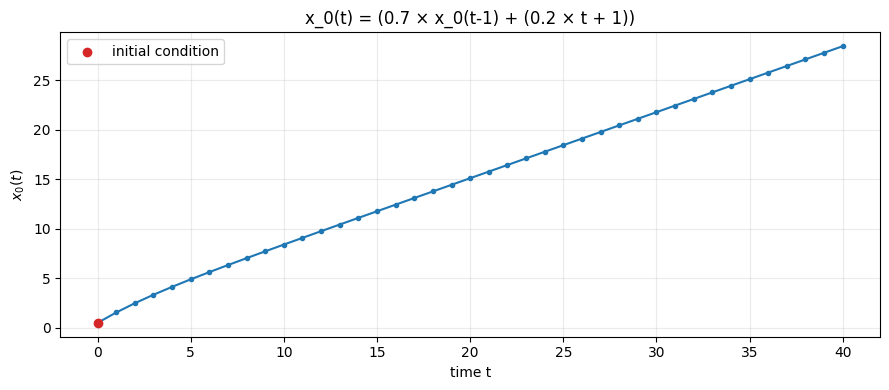

In [8]:
INITIAL_VALUES = [0.5]
GENERATED_STEPS = 40

formula_mechanism = FormulaMechanism(USER_FORMULA, target_variable=TARGET_VARIABLE)
series = formula_mechanism.generate(
    initial_values=INITIAL_VALUES,
    generated_steps=GENERATED_STEPS,
)

print(formula_mechanism.converted_formula)
print(f"Generated {len(series)} values including the initial condition.")
print("First 10 values:")
print(np.round(series[:10], 6))
print(f"Last value, x_0({len(series) - 1}): {series[-1]:.6f}")

figure, axis = formula_mechanism.plot()

**What this cell does.** It creates one mechanism object, asks that object to generate the trajectory, reads its converted formula, and calls its own `plot()` method. The autoregressive coefficient smooths the trajectory, while $0.2t+1.0$ introduces an increasing deterministic trend.

## 9. Verify the generated series and object contract

For every generated time, we recompute the right-hand side from the stored AST and compare it with the corresponding generated observation.

In [9]:
generation_start = len(INITIAL_VALUES)
residuals = np.asarray(
    [
        series[time]
        - evaluate_expression(formula_mechanism.expression, time, {TARGET_VARIABLE: series})
        for time in range(generation_start, len(series))
    ]
)
maximum_absolute_residual = float(np.max(np.abs(residuals)))

assert formula_mechanism.canonical_formula == to_canonical_formula(
    parse_formula(formula_mechanism.canonical_formula)
)
assert np.array_equal(formula_mechanism.series, series)
assert callable(formula_mechanism.plot)
assert "LAG(j, l)" in FormulaMechanism.instructions()
try:
    FormulaMechanism("sin(t)")
except ValueError as error:
    assert "FORMULA WRITING GUIDE" in str(error)
else:
    raise AssertionError("An unsupported formula must produce guided feedback.")
assert maximum_absolute_residual < 1e-12

print(f"Maximum absolute recurrence residual: {maximum_absolute_residual:.3e}")
print("Canonical formula round trip: passed")
print("Series recurrence check: passed")
print("Object API check: passed")
print("Invalid-formula guidance check: passed")

Maximum absolute recurrence residual: 0.000e+00
Canonical formula round trip: passed
Series recurrence check: passed
Object API check: passed
Invalid-formula guidance check: passed


**What this cell does.** It verifies the formula round trip, the generated recurrence, retained series, plotting method, and availability of the formula-writing instructions.

## 10. Compact user workflow

The complete public interaction now uses one stateful object. The returned object retains the mechanism and generated observations, so the user can inspect or plot them later.

In [10]:
result = FormulaMechanism(
    formula="0.7 * LAG(0, 1) + (0.2 * t + 1.0)",
    target_variable=0,
)
generated_values = result.generate(initial_values=[0.5], generated_steps=40)

print(result.converted_formula)
print(result.tree)
print("Series shape:", generated_values.shape)
print("Plot is available as: result.plot()")
print("Writing guide is available as: FormulaMechanism.instructions()")

x_0(t) = (0.7 × x_0(t-1) + (0.2 × t + 1))
ADD
├── MULTIPLY
│   ├── CONSTANT(0.7)
│   └── LAG(variable=0, lag=1)
└── ADD
    ├── MULTIPLY
    │   ├── CONSTANT(0.2)
    │   └── TIME
    └── CONSTANT(1)
Series shape: (41,)
Plot is available as: result.plot()
Writing guide is available as: FormulaMechanism.instructions()


**What this cell does.** It shows the minimal final API: construct the object, generate the series, inspect the converted formula or AST, and call `result.plot()` whenever a visualization is needed.

## Result and next step

The example establishes a lossless and executable path between a user formula, its AST, and the generated trajectory. The public object now communicates the formula grammar and owns its visualization. The next implementation step is to move the tested AST, evaluator, and `FormulaMechanism` into the reusable library, add JSON serialization, and test several manually defined formulas before introducing random tree sampling.